# NLP Sentiment Classifer

## Load in data and imports

* Building a simple insight sentiment classifier.

* We will use the GoEmotions datset from Google.
  - https://github.com/google-research/google-research/tree/master/goemotions?utm_source=chatgpt.com

* GoEmotions is a corpus of 58k carefully curated comments extracted from Reddit, with human annotations to 27 emotion categories or Neutral.
  - Number of examples: 58,009.

  - Number of labels: 27 + Neutral.

  - Maximum sequence length in training and evaluation datasets: 30.

* On top of the raw data, we also include a version filtered based on reter-agreement, which contains a train/test/validation split:
  - Size of training dataset: 43,410.

  - Size of test dataset: 5,427.

  - Size of validation dataset: 5,426.

* The emotion categories are: admiration, amusement, anger, annoyance, approval, caring, confusion, curiosity, desire, disappointment, disapproval, disgust, embarrassment, excitement, fear, gratitude, grief, joy, love, nervousness, optimism, pride, realization, relief, remorse, sadness, surprise.


## Data Format

* Our raw dataset, split into three csv files, includes all annotations as well as metadata on the comments. Each row represents a single rater's annotation for a single example. This file includes the following columns:

  - text: The text of the comment (with masked tokens, as described in the paper).
  
  - id: The unique id of the comment.
  
  - author: The Reddit username of the comment's author.
  
  - subreddit: The subreddit that the comment belongs to.
  
  - link_id: The link id of the comment.
  
  - parent_id: The parent id of the comment.
  
  - created_utc: The timestamp of the comment.
  
  - rater_id: The unique id of the annotator.
  
  - example_very_unclear: Whether the annotator marked the example as being very unclear or difficult to label (in this case they did not choose any emotion labels).
  
  - separate columns representing each of the emotion categories, with binary labels (0 or 1)

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:
# Load in the data in terminal.
# wget -P data/full_dataset/ https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_1.csv
# wget -P data/full_dataset/ https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_2.csv
# wget -P data/full_dataset/ https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_3.csv

In [3]:
df1 = pd.read_csv("data/full_dataset/goemotions_1.csv")
df1.head()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1


In [4]:
df1.shape

(70000, 37)

In [5]:
df2 = pd.read_csv("data/full_dataset/goemotions_2.csv")
df2.head()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,We can hope,ee3o3ko,darkenseyreth,EdmontonOilers,t3_ag4r9j,t1_ee3mhad,1.547529e+09,62,False,0,...,0,0,1,0,0,0,0,0,0,0
1,Shhh don't give them the idea!,eebl3z7,BoinkBoinkEtAliae,MurderedByWords,t3_ah3o76,t1_eeb68lo,1.547777e+09,76,False,0,...,0,0,0,0,0,0,0,0,0,0
2,"Thank you so much, kind stranger. I really nee...",ed4fe9l,savageleaf,raisedbynarcissists,t3_abwh00,t1_ed4etbj,1.546482e+09,24,False,0,...,0,0,0,0,0,0,0,0,0,0
3,Ion know but it would be better for you to jus...,efavtdu,CADDiLLXC,darknet,t3_al4njw,t3_al4njw,1.548800e+09,62,False,0,...,0,0,0,0,0,0,0,0,0,1
4,I'm honestly surprised. We should have fallen ...,ee2imz2,CorporalThornberry,CollegeBasketball,t3_afxt6t,t1_ee22nyr,1.547497e+09,55,False,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df2.shape

(70000, 37)

In [7]:
df3 = pd.read_csv("data/full_dataset/goemotions_3.csv")
df3.head()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,Worst ending ever! I won't spoil it but this o...,eee021b,tribaltrak,movies,t3_agxbsx,t3_agxbsx,1.547847e+09,42,False,0,...,0,0,0,0,0,0,0,0,0,0
1,Happy cake day u/sneakpeekbot!,ed00f1z,InfernicFuse,danganronpa,t3_abajdo,t1_eczoocj,1.546328e+09,24,False,0,...,0,0,0,0,0,0,0,0,0,0
2,Was he rejected because of his methodology or ...,ee1h5v1,OssToYouGoodSir,medicine,t3_aflo7s,t1_ee0v0vv,1.547464e+09,77,False,0,...,0,0,0,0,0,0,0,0,0,0
3,"thanks, I agree",eemi935,PMOFreeForever,NoFap,t3_ai7h09,t1_eelu54r,1.548088e+09,46,False,0,...,0,0,0,0,0,0,0,0,0,0
4,Why would you doubt it dumbass?,eduun99,ugliestman1,Tinder,t3_aejwne,t1_edumeal,1.547255e+09,36,False,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
df3.shape

(71225, 37)

In [9]:
df1.columns

Index(['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id',
       'created_utc', 'rater_id', 'example_very_unclear', 'admiration',
       'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion',
       'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust',
       'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy',
       'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief',
       'remorse', 'sadness', 'surprise', 'neutral'],
      dtype='str')

In [10]:
# Combine all 3 datasets.
df = pd.concat([df1, df2, df3], ignore_index=True)

In [11]:
df.shape

(211225, 37)

In [12]:
df.head()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1


In [13]:
df.columns

Index(['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id',
       'created_utc', 'rater_id', 'example_very_unclear', 'admiration',
       'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion',
       'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust',
       'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy',
       'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief',
       'remorse', 'sadness', 'surprise', 'neutral'],
      dtype='str')

In [14]:
df["text"].head(10)

0                                      That game hurt.
1     >sexuality shouldn’t be a grouping category I...
2       You do right, if you don't care then fuck 'em!
3                                   Man I love reddit.
4    [NAME] was nowhere near them, he was by the Fa...
5    Right? Considering it’s such an important docu...
6    He isn't as big, but he's still quite popular....
7    That's crazy; I went to a super [RELIGION] hig...
8                                  that's adorable asf
9    "Sponge Blurb Pubs Quaw Haha GURR ha AAa!" fin...
Name: text, dtype: str

In [15]:
# Verify the emotions
df.iloc[:, 8:].sum().sort_values(ascending=False)

neutral                 55298
approval                17620
admiration              17131
annoyance               13618
gratitude               11625
disapproval             11424
curiosity                9692
amusement                9245
realization              8785
optimism                 8715
disappointment           8469
love                     8191
anger                    8084
joy                      7983
confusion                7359
sadness                  6758
caring                   5999
excitement               5629
surprise                 5514
disgust                  5301
desire                   3817
example_very_unclear     3411
fear                     3197
remorse                  2525
embarrassment            2476
nervousness              1810
pride                    1302
relief                   1289
grief                     673
dtype: int64

## Loading in the training data.

* Using the official preprocessed GoEmotions training split.

* Each text example is associated with one or more emotion labels.

* For this project, we will create a SINGLE-label classification task.

In [16]:
# Load the training data.
train_df = pd.read_csv(
    "data/preprocessed/train.tsv",
    sep="\t",
    header=None,
    names=["text", "emotion_ids", "id"]
)

train_df.head()

,text,emotion_ids,id
0,My favourite food is anything I didn't have to...,27,eebbqej
1,"Now if he does off himself, everyone will thin...",27,ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj
3,To make her feel threatened,14,ed7ypvh
4,Dirty Southern Wankers,3,ed0bdzj


In [17]:
print(train_df.columns)

Index(['text', 'emotion_ids', 'id'], dtype='str')


In [18]:
print(train_df.shape)

(43410, 3)


## EDA

In [19]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43410 entries, 0 to 43409
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   text         43410 non-null  str  
 1   emotion_ids  43410 non-null  str  
 2   id           43410 non-null  str  
dtypes: str(3)
memory usage: 1017.6 KB


* We have 43,140 rows with no missing or null values.

* The data type for all rows are strings.

In [20]:
# Most common emotion ID in the training set?
train_df['emotion_ids'].value_counts()

emotion_ids
27            12823
0              2710
4              1873
15             1857
1              1652
              ...  
0,12,13,26        1
1,2,5,17          1
13,14             1
3,9,12            1
0,1,18            1
Name: count, Length: 711, dtype: int64

In [21]:
# 27 is the most common id with a count of 12823.

# Some class imblance.

train_df['emotion_ids'].value_counts().head(20)

emotion_ids
27    12823
0      2710
4      1873
15     1857
1      1652
3      1451
18     1427
10     1402
7      1389
2      1025
20      861
6       858
17      853
25      817
26      720
9       709
5       649
22      586
13      510
11      498
Name: count, dtype: int64

* GoEmotions has a fixed mapping from IDs to emotions.
  - admiration
amusement
anger
annoyance
approval
caring
confusion
curiosity
desire
disappointment
disapproval
disgust
embarrassment
excitement
fear
gratitude
grief
joy
love
nervousness
optimism
pride
realization
relief
remorse
sadness
surprise
neutral

In [22]:
emotion_labels = [
    "admiration", "amusement", "anger", "annoyance", "approval",
    "caring", "confusion", "curiosity", "desire", "disappointment",
    "disapproval", "disgust", "embarrassment", "excitement", "fear",
    "gratitude", "grief", "joy", "love", "nervousness", "optimism",
    "pride", "realization", "relief", "remorse", "sadness",
    "surprise", "neutral"
]

for i, emotion in enumerate(emotion_labels):
  print(i, emotion)

0 admiration
1 amusement
2 anger
3 annoyance
4 approval
5 caring
6 confusion
7 curiosity
8 desire
9 disappointment
10 disapproval
11 disgust
12 embarrassment
13 excitement
14 fear
15 gratitude
16 grief
17 joy
18 love
19 nervousness
20 optimism
21 pride
22 realization
23 relief
24 remorse
25 sadness
26 surprise
27 neutral


In [23]:
train_df['emotion_ids'].nunique()

711

In [24]:
# Some of the dataset is multi-labled, NOT single-labeled.

# Hence why we ended up 711 unique values.
train_df["emotion_ids"].unique()[:30]

<StringArray>
[    '27',      '2',     '14',      '3',     '26',     '15',   '8,20',
      '0',      '6',    '1,4',      '5',   '3,12',   '6,22', '6,9,27',
     '12',  '16,25',    '2,7',     '17',     '25',   '0,15',  '15,18',
  '16,27',   '7,13',     '10',     '20',      '4',  '13,15',    '0,1',
     '13',      '1']
Length: 30, dtype: str

In [25]:
# Multi-labeled emotion id's contain ",", so let's count how many are multi-labeled.
train_df['emotion_ids'].str.contains(',').value_counts()

emotion_ids
False    36308
True      7102
Name: count, dtype: int64

In [26]:
train_df['emotion_ids'].str.contains(',').value_counts()

emotion_ids
False    36308
True      7102
Name: count, dtype: int64

In [27]:
total_count = len(train_df)
multi_labeled_count = train_df['emotion_ids'].str.contains(',').sum()
single_labeled_count = (~train_df['emotion_ids'].str.contains(',')).sum()

print(f"Total data points: {total_count}")
print(f"Single-labeled data points: {single_labeled_count}")
print(f"Multi-labeled data points: {multi_labeled_count}")

Total data points: 43410
Single-labeled data points: 36308
Multi-labeled data points: 7102


## Single-Labeled Data

* For this project, we will work with just the single-labeled data points.

* That gives us 36308 data points.

In [28]:
single_label_df = train_df[
  ~(train_df['emotion_ids'].str.contains(','))
].copy()

In [29]:
single_label_df.head()

,text,emotion_ids,id
0,My favourite food is anything I didn't have to...,27,eebbqej
1,"Now if he does off himself, everyone will thin...",27,ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj
3,To make her feel threatened,14,ed7ypvh
4,Dirty Southern Wankers,3,ed0bdzj


In [30]:
single_label_df.shape

(36308, 3)

In [31]:
# Convert emotion_ids to int.
single_label_df['emotion_ids'] = single_label_df['emotion_ids'].astype(int)
single_label_df.head()

,text,emotion_ids,id
0,My favourite food is anything I didn't have to...,27,eebbqej
1,"Now if he does off himself, everyone will thin...",27,ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj
3,To make her feel threatened,14,ed7ypvh
4,Dirty Southern Wankers,3,ed0bdzj


### Mapping the Emotion IDs

In [32]:
single_label_df['emotion_ids']

0        27
1        27
2         2
3        14
4         3
         ..
43405    18
43406     6
43407     3
43408    13
43409    17
Name: emotion_ids, Length: 36308, dtype: int64

In [33]:
with open("data/preprocessed/emotions.txt") as f:
  emotion_labels = [line.strip() for line in f if line.strip()]

emotion_labels

['admiration',
 'amusement',
 'anger',
 'annoyance',
 'approval',
 'caring',
 'confusion',
 'curiosity',
 'desire',
 'disappointment',
 'disapproval',
 'disgust',
 'embarrassment',
 'excitement',
 'fear',
 'gratitude',
 'grief',
 'joy',
 'love',
 'nervousness',
 'optimism',
 'pride',
 'realization',
 'relief',
 'remorse',
 'sadness',
 'surprise',
 'neutral']

In [34]:
emotion_mapping = dict(enumerate(emotion_labels))
emotion_mapping

{0: 'admiration',
 1: 'amusement',
 2: 'anger',
 3: 'annoyance',
 4: 'approval',
 5: 'caring',
 6: 'confusion',
 7: 'curiosity',
 8: 'desire',
 9: 'disappointment',
 10: 'disapproval',
 11: 'disgust',
 12: 'embarrassment',
 13: 'excitement',
 14: 'fear',
 15: 'gratitude',
 16: 'grief',
 17: 'joy',
 18: 'love',
 19: 'nervousness',
 20: 'optimism',
 21: 'pride',
 22: 'realization',
 23: 'relief',
 24: 'remorse',
 25: 'sadness',
 26: 'surprise',
 27: 'neutral'}

In [35]:
# Map the IDs in dataframe.
single_label_df['emotion'] = single_label_df['emotion_ids'].map(emotion_mapping)
single_label_df.head()

,text,emotion_ids,id,emotion
0,My favourite food is anything I didn't have to...,27,eebbqej,neutral
1,"Now if he does off himself, everyone will thin...",27,ed00q6i,neutral
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj,anger
3,To make her feel threatened,14,ed7ypvh,fear
4,Dirty Southern Wankers,3,ed0bdzj,annoyance


In [36]:
# Check on Class Distribution.
class_distribution = single_label_df['emotion'].value_counts()
class_distribution

emotion
neutral           12823
admiration         2710
approval           1873
gratitude          1857
amusement          1652
annoyance          1451
love               1427
disapproval        1402
curiosity          1389
anger              1025
optimism            861
confusion           858
joy                 853
sadness             817
surprise            720
disappointment      709
caring              649
realization         586
excitement          510
disgust             498
fear                430
desire              389
remorse             353
embarrassment       203
relief               88
nervousness          85
pride                51
grief                39
Name: count, dtype: int64

In [37]:
print(f"Number of emotion classes: {single_label_df['emotion'].nunique()}")
print(f"Most common emotion: {class_distribution.index[0]} ({class_distribution.iloc[0]:,})")
print(f"Least common emotion: {class_distribution.index[-1]} ({class_distribution.iloc[-1]:,})")

Number of emotion classes: 28
Most common emotion: neutral (12,823)
Least common emotion: grief (39)


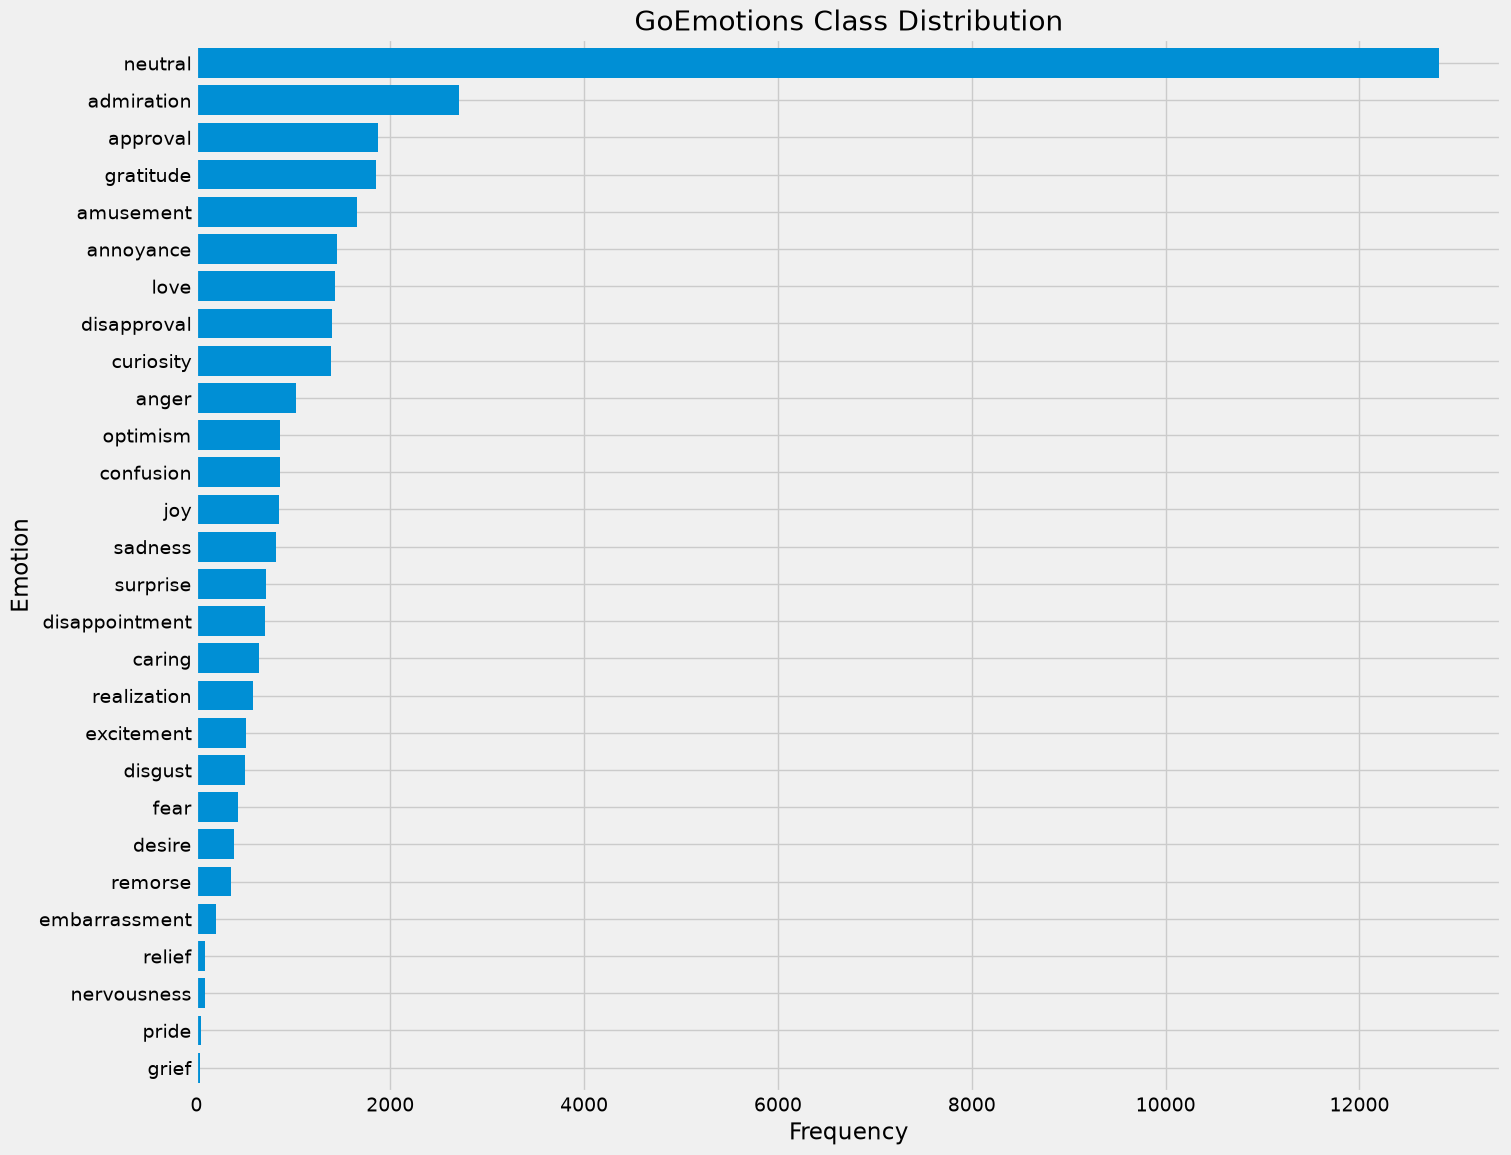

In [38]:
plt.style.use('fivethirtyeight')
class_distribution.sort_values().plot(
    kind="barh",
    figsize=(15, 13), 
    width=0.8
)

plt.xlabel("Frequency")
plt.ylabel("Emotion")
plt.title("GoEmotions Class Distribution")
plt.show()

In [39]:
class_distribution.index

Index(['neutral', 'admiration', 'approval', 'gratitude', 'amusement',
       'annoyance', 'love', 'disapproval', 'curiosity', 'anger', 'optimism',
       'confusion', 'joy', 'sadness', 'surprise', 'disappointment', 'caring',
       'realization', 'excitement', 'disgust', 'fear', 'desire', 'remorse',
       'embarrassment', 'relief', 'nervousness', 'pride', 'grief'],
      dtype='str', name='emotion')

In [40]:
class_distribution.values

array([12823,  2710,  1873,  1857,  1652,  1451,  1427,  1402,  1389,
        1025,   861,   858,   853,   817,   720,   709,   649,   586,
         510,   498,   430,   389,   353,   203,    88,    85,    51,
          39])

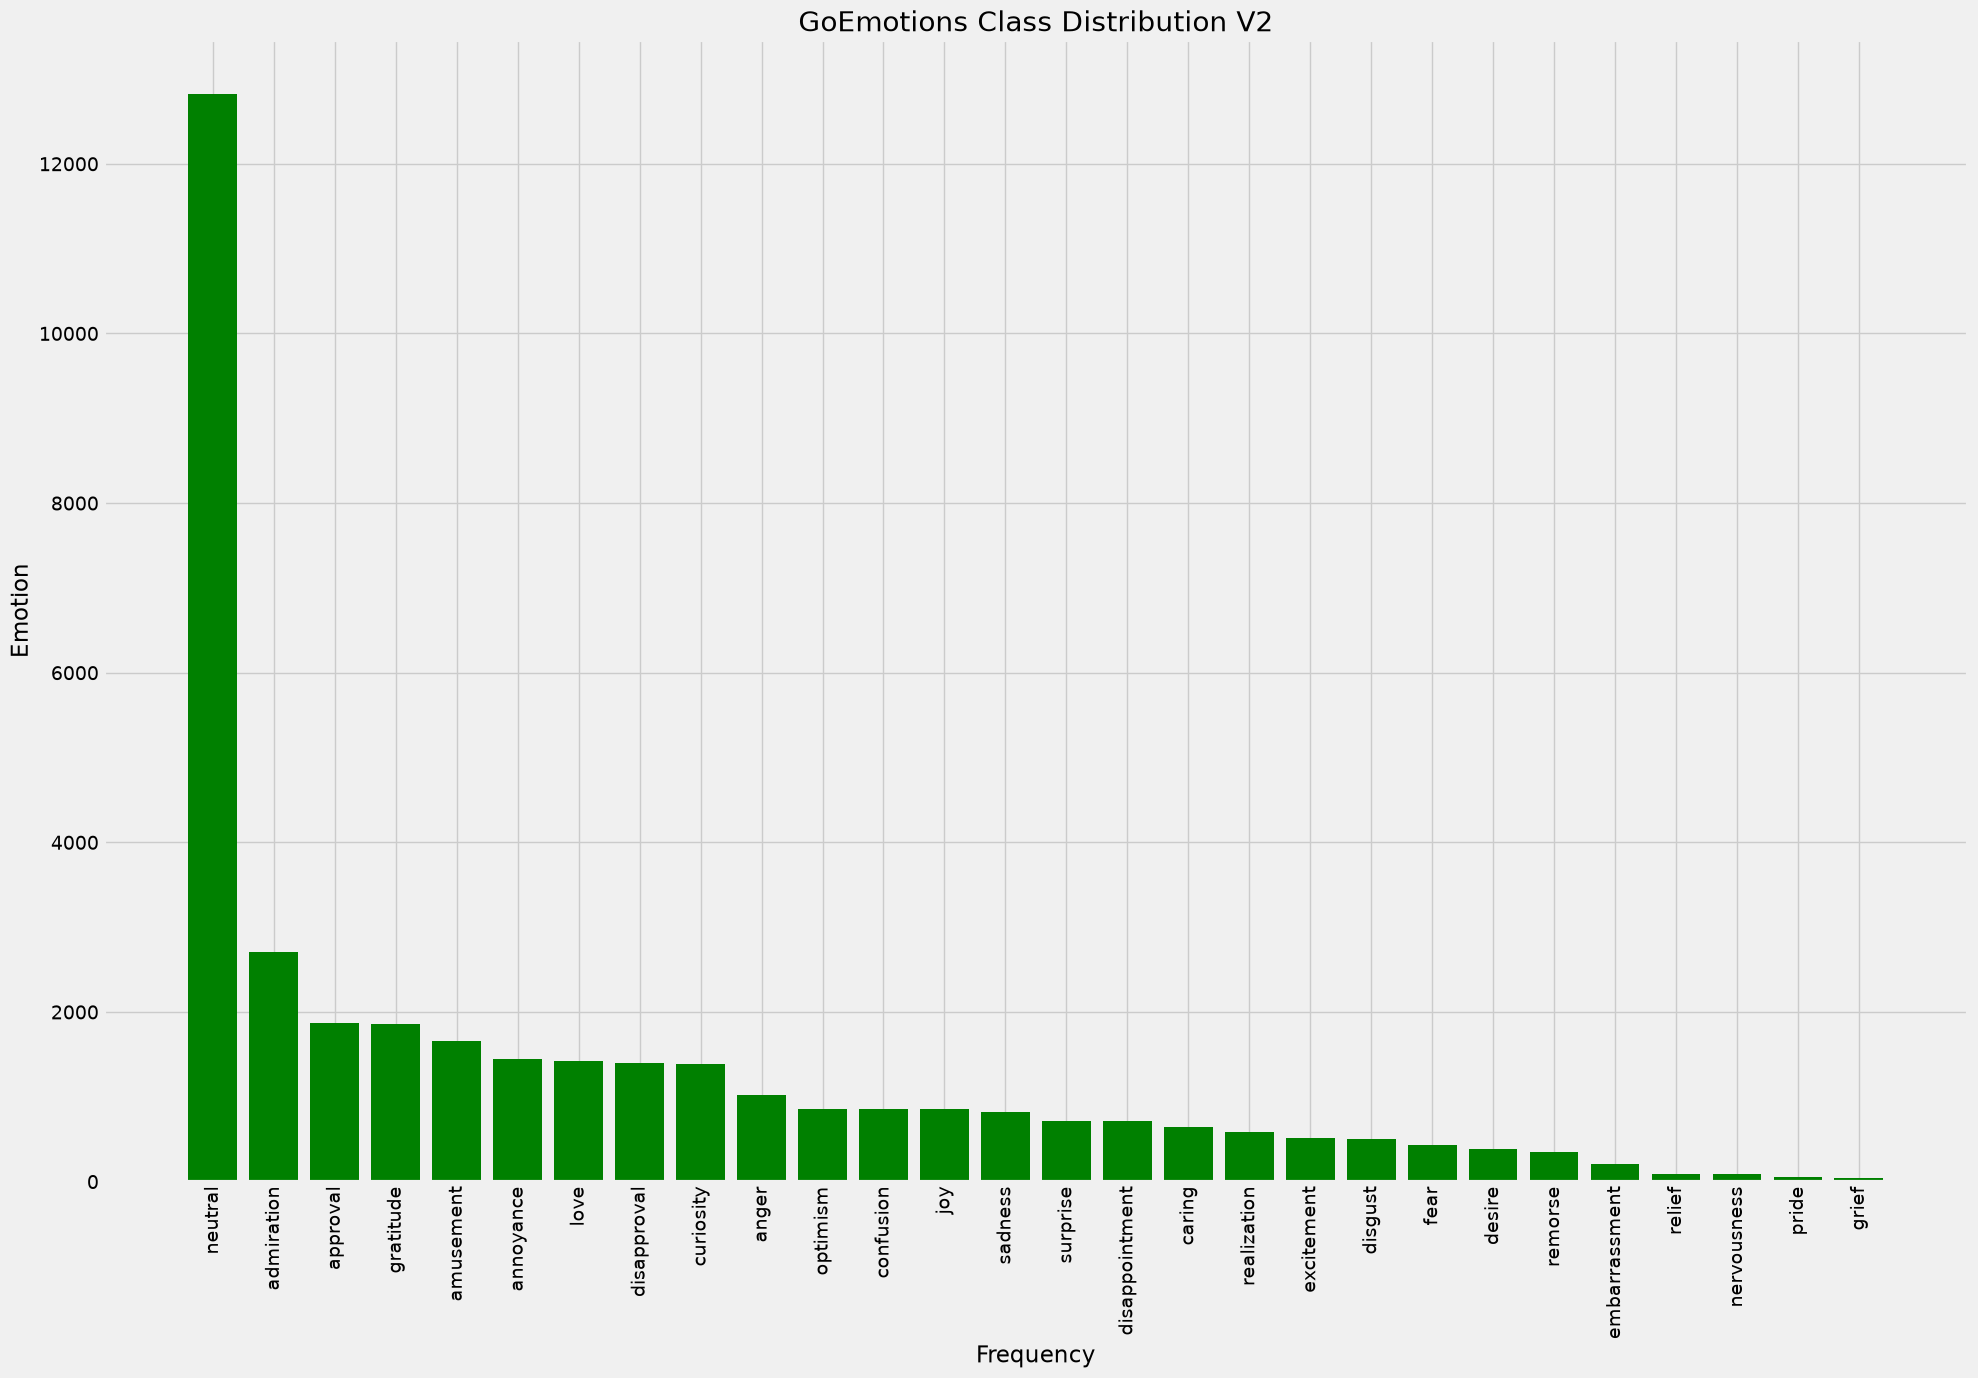

In [41]:
plt.style.use('fivethirtyeight')

plt.figure(figsize=(20, 14))
width=0.8

plt.bar(class_distribution.index, class_distribution.values, width=width, color='green')

plt.title("GoEmotions Class Distribution V2")
plt.xlabel("Frequency")
plt.ylabel("Emotion")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [42]:
# Validate there are no missing values.
print(single_label_df[['text', 'emotion']].isnull().sum())

text       0
emotion    0
dtype: int64


### TF-IDF (Term Frequency and Inverse Document Frequency)

* TF = Term Frequency
  - How often does a word appear in the specific text?

  - EX: "I am really happy and happy today"
    - "happy" appears TWICE. --> leads to relatively higher TF(more importance).

* IDF = Inverse Document Frequency
  - How common is the word across the entire dataset?

  - EX: If "happy" appears in only a SMALL portion of thousands of comments, it's potentially USEFUL for distinguishing emotions.

  - EX: The word "the" appears in almost every comment, it isn't very useful for distinguishing emotions. 
    - TF-IDF then gives it a LOWER weight.

* We will use TF-IDF for feature engineering. 
  - It essentially asks which words/phrases in our text document are informative.

* Logistic Regression model will need the words to be converted into nuemrical input.

## X and Y Training Split

In [43]:
single_label_df.head()

,text,emotion_ids,id,emotion
0,My favourite food is anything I didn't have to...,27,eebbqej,neutral
1,"Now if he does off himself, everyone will thin...",27,ed00q6i,neutral
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj,anger
3,To make her feel threatened,14,ed7ypvh,fear
4,Dirty Southern Wankers,3,ed0bdzj,annoyance


In [44]:
x = single_label_df['text']
x.head()

0    My favourite food is anything I didn't have to...
1    Now if he does off himself, everyone will thin...
2                       WHY THE FUCK IS BAYLESS ISOING
3                          To make her feel threatened
4                               Dirty Southern Wankers
Name: text, dtype: str

In [45]:
y = single_label_df['emotion']
y

0           neutral
1           neutral
2             anger
3              fear
4         annoyance
            ...    
43405          love
43406     confusion
43407     annoyance
43408    excitement
43409           joy
Name: emotion, Length: 36308, dtype: str

In [46]:
print(f'Features: {x.shape}')
print(f'Target: {y.shape}')

Features: (36308,)
Target: (36308,)


### Splitting the data into training and test sets.

* stratify() ensures the proportion of different classes in our target stays approximately the same in both training and testing sets.

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
X_train, X_val, y_train, y_val = train_test_split(
  x, 
  y, 
  test_size=0.33, 
  random_state=42, 
  stratify=y
)

In [49]:
print(f'Training Data: {len(X_train)}')
print(f'Validation Data: {len(X_val)}')

Training Data: 24326
Validation Data: 11982


In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

* ngram_range=(1, 2) → learns from both individual words and 2-word phrases.
  - We are creating features for every individual word AND every 2-word sequence.
  - EX:
    - "sad" = unigram

    - "feel sad" = bigram

  - EX: "I feel really sad"
    - Unigrams:
      - I
      - feel
      - really
      - sad
    
    - Bigrams:
      - I feel 
      - feel really
      - really sad

  - EX: "I am not happy". 
    - Without bigrams, we'd wouldn't have "not happy", which differs...
    - ...from when the word "happy" appears in this sentence and a sentence like "I am happy".

    - Unigrams:
      - I
      - am 
      - not
      - happy
    
    - Bigrams:
      - I am
      - am not
      - not happy

  - EX: "I absolutely love this" --> Model can learn that "absolutely love" is an especially strong phase.
    - Unigrams:
      - I
      - absolutely
      - love 
      - this
    
    - Bigrams:
      - I absolutely 
      - absolutely love
      - love this

* min_df=2 --> How frequently a feature has to appear before TF-IDF considers it useful enough to keep.
  - Keep a word/phrase only if it appears in at least 2 different training text/DOCUMENTS.

  - NOT the frequency. If the word "happy" appears 4 times in only ONE document, it would NOT be included since the minimum requirement is 2.

  - EX: We keep "feel", "happy", "today"
    - 1. "I feel happy today"
    - 2. "I feel sad today"
    - 3. "I feel happy"
    - 4. "This is amazing"

* "min_df" applies to BIGRAMS too.
  - EX: 
    - Document 1: "I feel happy"
    - Document 2: "I feel sad"
    - Document 3: "I feel happy"
  
  * Potential bigrams include:
    - I feel
    - feel happy
    - feel sad

  * Their document frequencies are:
    - "I feel"     → 3 documents
    - "feel happy" → 2 documents
    - "feel sad"   → 1 document
  
  * With "min_df=2", we keep:
    - I feel
    - feel happy


In [51]:
# "Look at individual words and 2-word phrases, but exclude any word or phrase that appears in only ONE training example/document."
tfidf = TfidfVectorizer(
  ngram_range=(1, 2), 
  min_df=2
)

In [52]:
tfidf

,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None


In [53]:
# Learns the vocabulary and TF-IDF weights only from the training data.
x_train_tfidf = tfidf.fit_transform(X_train)
# Apply that learned vocabulary to validation data. 
# Use only "transform" on validation set, because we do NOT want data leakage where info from the validation set enters the training set.
x_val_tfidf = tfidf.transform(X_val)

print(f"Training TF-IDF shape: {x_train_tfidf.shape}")
print(f"Validation TF-IDF shape: {x_val_tfidf.shape}")

Training TF-IDF shape: (24326, 35522)
Validation TF-IDF shape: (11982, 35522)


In [54]:
x_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 420390 stored elements and shape (24326, 35522)>

In [55]:
x_val_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 191337 stored elements and shape (11982, 35522)>

* We ended up with 35,522 features, which could consist of a mix of unigrams and bigrams.

In [56]:
# Looking into what those 35,522 features actually are.
feature_names = tfidf.get_feature_names_out()

print(f'Number of features: {len(feature_names)}')
print(feature_names[:50])

Number of features: 35522
['00' '000' '000 dollars' '000 fine' '000 people' '01' '05' '10' '10 000'
 '10 10' '10 15' '10 20' '10 but' '10 for' '10 games' '10 hours' '10 mins'
 '10 minute' '10 minutes' '10 of' '10 on' '10 seconds' '10 times'
 '10 words' '10 would' '10 year' '10 years' '100' '100 in' '100 name'
 '100 of' '100 scam' '100 sure' '100 the' '100 times' '100 years' '1000'
 '100k' '101' '10k' '10th' '10x' '11' '11 10' '11 years' '11am' '12'
 '12 episodes' '12 hours' '12 year']


## Logistic Regression Classifier

In [57]:
from sklearn.linear_model import LogisticRegression

In [58]:
# Balance class weights, since our dataset has extremely imbalanced classes. 
# Recall that "neutral" has 12,823 examples while "grief: has only 39.
lr_model = LogisticRegression(
  max_iter=1000, 
  class_weight='balanced', 
  random_state=42
)

lr_model.fit(x_train_tfidf, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

In [59]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report

In [60]:
y_pred = lr_model.predict(x_val_tfidf)

print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")

# Calculates F1 separately for each of the 28 emotions and gives every emotion equal weight. This is particularly important because the classes are extremely imbalanced.
print(f"Macro F1: {f1_score(y_val, y_pred, average='macro'):.4f}")

# Gives more weight to emotions with more examples.
print(f"Weighted F1: {f1_score(y_val, y_pred, average='weighted'):.4f}")

Accuracy: 0.4029
Macro F1: 0.3851
Weighted F1: 0.3980


In [61]:
print(classification_report(y_val, y_pred))

                precision    recall  f1-score   support

    admiration       0.59      0.61      0.60       894
     amusement       0.73      0.77      0.75       545
         anger       0.40      0.46      0.43       338
     annoyance       0.14      0.14      0.14       479
      approval       0.25      0.28      0.26       618
        caring       0.17      0.52      0.26       214
     confusion       0.25      0.43      0.31       283
     curiosity       0.30      0.52      0.38       458
        desire       0.33      0.66      0.44       128
disappointment       0.13      0.24      0.17       234
   disapproval       0.20      0.41      0.26       463
       disgust       0.28      0.44      0.34       164
 embarrassment       0.30      0.45      0.36        67
    excitement       0.21      0.36      0.26       168
          fear       0.37      0.53      0.44       142
     gratitude       0.92      0.85      0.89       613
         grief       0.12      0.15      0.13  

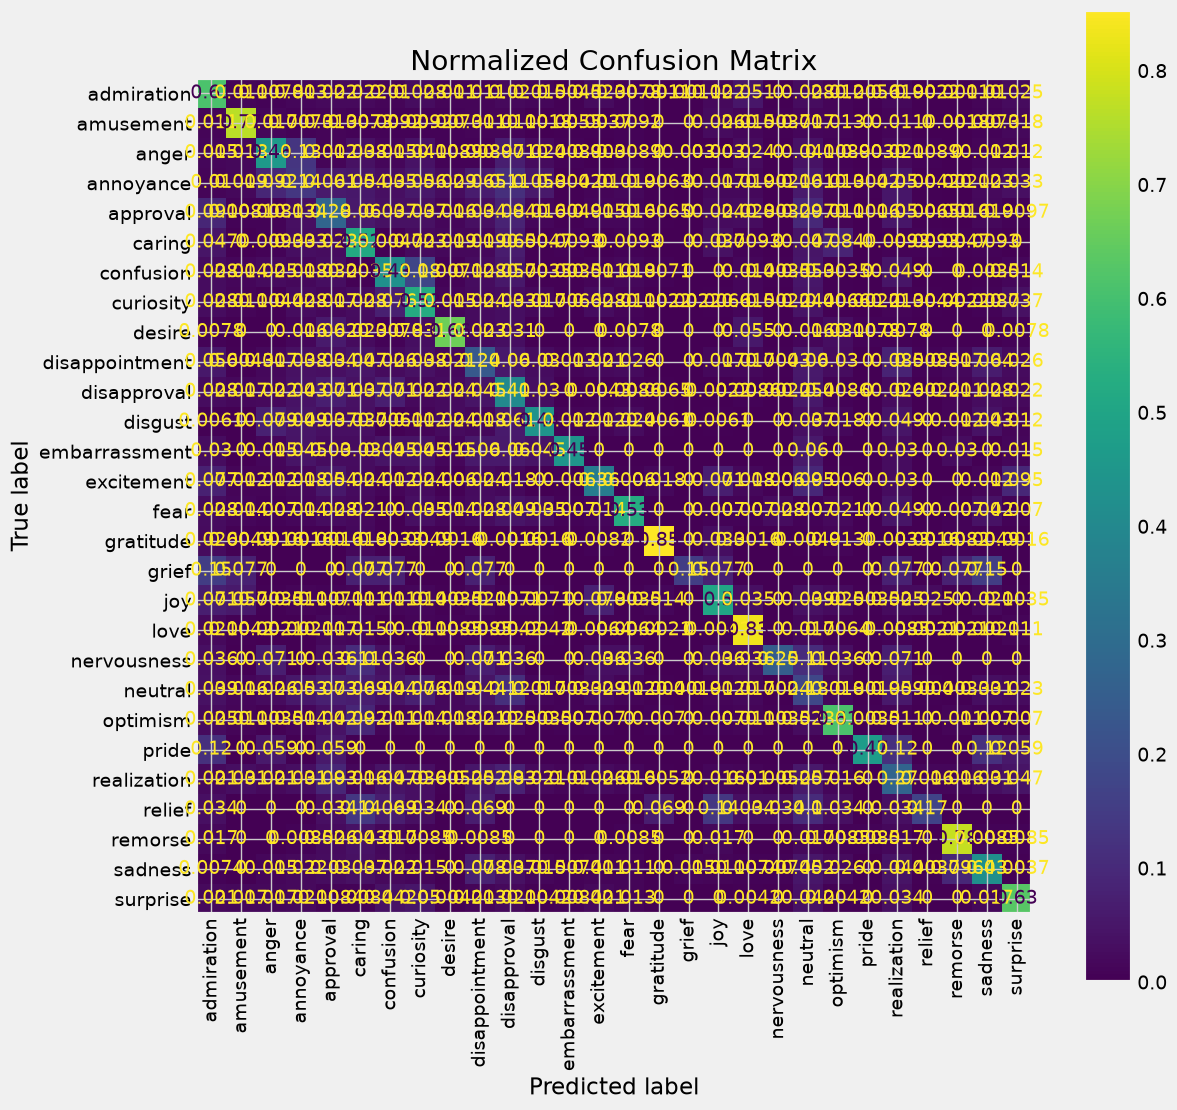

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred,
    xticks_rotation="vertical",
    normalize="true",
    ax=ax
)

plt.title("Normalized Confusion Matrix")
plt.show()

In [66]:
# Looking into feature importance.
feature_names = tfidf.get_feature_names_out()

print(f'Number of features: {len(feature_names)}')
print(f"Number of classes: {len(lr_model.classes_)}")

Number of features: 35522
Number of classes: 28


In [67]:
top_features = {}

for i, emotion in enumerate(lr_model.classes_):
    coefficients = lr_model.coef_[i]
    top_indices = coefficients.argsort()[-10:][::-1]
    
    top_features[emotion] = [
        (feature_names[j], coefficients[j])
        for j in top_indices
    ]

top_features_df = pd.DataFrame(
    top_features,
    index=range(1, 11)
)

top_features_df

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,love,nervousness,neutral,optimism,pride,realization,relief,remorse,sadness,surprise
1,"(great, 9.478392660823705)","(lol, 17.310005014324698)","(fuck, 8.451550260055043)","(stupid, 4.436914715824319)","(agree, 6.580928335061963)","(you, 6.5082919107712245)","(confused, 6.372953151010952)","(curious, 6.50669958188909)","(wish, 14.990928979601746)","(disappointed, 5.036703700810069)",...,"(love, 19.405306251731293)","(nervous, 6.576445509161267)","(name, 1.85792139483908)","(hope, 13.98071623824797)","(proud, 7.913833111251357)","(realized, 5.219059399737157)","(glad, 7.2845096046268765)","(sorry, 17.76111630341356)","(sad, 11.278505979554307)","(surprised, 10.932703706242332)"
2,"(good, 6.604370230238821)","(haha, 8.693769664129652)","(fucking, 6.483257659166971)","(annoying, 3.9894296619801297)","(yes, 4.083677541573263)","(careful, 4.277121454194623)","(not sure, 5.298690450384889)","(what, 4.844425873604725)","(want, 7.186423542803609)","(disappointing, 4.603161826409806)",...,"(loved, 7.050405653236659)","(worried, 5.67080846165112)","(they, 1.6488614525294232)","(hopefully, 7.732085196820884)","(pride, 5.224430035254293)","(realize, 5.10855323983596)","(relief, 5.701425140072924)","(regret, 5.598071167742103)","(sadly, 7.131841880355263)","(wow, 8.69482380670524)"
3,"(awesome, 6.090894986370548)","(funny, 7.728235943259717)","(hate, 5.747500758748918)","(shit, 2.6107556387682003)","(right, 3.9375130088959054)","(yourself, 4.223246837211106)","(why, 5.169265663962903)","(why, 4.524818345852418)","(need, 5.166084425636544)","(miss, 3.4386886302857325)",...,"(like, 6.605073170907728)","(worrying, 5.573571404177432)","(he, 0.8940143485931363)","(hoping, 6.561979110263404)","(have these, 4.148029813653707)","(forgot, 3.188472534805128)","(at least, 3.8873836079198343)","(guilty, 4.509176329305325)","(sorry, 5.934456869135137)","(wonder, 6.424068023458433)"
4,"(amazing, 5.964324339760865)","(lmao, 6.345176798658793)","(angry, 3.904862062564271)","(fucking, 2.119676760577798)","(yeah, 3.6258636359207963)","(worry, 4.191802535282939)","(or, 4.903574384073668)","(do you, 4.099584487984585)","(wanted, 3.7886839635368874)","(bad, 3.361121927450804)",...,"(loves, 4.242536926671875)","(anxiety, 5.489329329413518)","(she, 0.7772311681964654)","(luck, 4.458254328243051)","(myself, 4.038177387316856)","(remember, 2.8078002798712647)","(relaxed, 3.830030350002669)","(apologize, 3.541578911087156)","(hurts, 4.323157045285327)","(omg, 4.80543330323569)"
5,"(beautiful, 5.439727623665223)","(fun, 5.804645301425558)","(stupid, 3.44730423216534)","(stop, 2.105181895925306)","(sure, 3.5979562805481957)","(your, 4.15046436404708)","(don, 4.114388095093031)","(did, 3.6785311720578)","(hope, 3.673621064003858)","(disappointment, 3.2460907110779407)",...,"(favorite, 3.4592741067526735)","(anxious, 5.13143242572929)","(on, 0.7229335973515604)","(hope you, 3.5475531379378076)","(so proud, 3.7386127235692395)","(thought, 2.731873221337816)","(thank god, 3.7400782803262858)","(apologies, 3.4585063782609025)","(poor, 4.257954621943483)","(shocked, 4.734439940083437)"
6,"(nice, 4.976091629152006)","(hilarious, 5.326812408279178)","(shut, 3.070304370517374)","(fuck, 2.0355579310563603)","(agreed, 2.920590279211453)","(don worry, 3.866588414898037)","(don know, 3.8766526376206705)","(is that, 3.6578166197449016)","(to, 2.9705080225266443)","(lost, 3.244440592297822)",...,"(loving, 2.805057908912256)","(edgy, 4.765021189294632)","(remindme, 0.6910436905032646)","(will, 3.503248135755755)","(with pride, 3.341745404245959)","(was, 2.4804677995484847)","(least, 3.6794833538438705)","(sorry but, 2.9286582042445577)","(miss, 3.7797531838985723)","(can believe, 4.7033460794869395)"
7,"(best, 4.086450071292003)","(hahaha, 5.048787785063773)","(dare, 3.0304329736888174)","(you, 1.9875994593316557)","(ok, 2.6004705012714324)","(stay, 3.8332546900831312)","(sure, 3.80553